# I. Giới thiệu
Nội dung đề tài là: Phân tích thống kê và hồi quy tuyến tính đơn về mối quan hệ
giữa thời gian tập Cardio và lượng calo đốt được ở nam giới

# II. Mô tả bộ dữ liệu
Sử dụng pandas để đọc và lọc dữ liệu.

In [15]:
import pandas as pd

def process_workout_data(input_path, output_path):
    # read the raw data
    df = pd.read_csv(input_path)

    #filter the data based on the specified criteria
    filtered_df = df.loc[
        (df['Age'].between(18, 25)) & 
        (df['Gender'] == 'Male') & 
        (df['Workout_Type'] == 'Cardio'),
        ['Age', 'Gender', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type']
    ]

    # Save the filtered data to a new CSV file
    #filtered_df.to_csv(output_path, index=False)
    print(f"Đã xử lý xong. Dữ liệu mới có {len(filtered_df)} dòng.")
    print(filtered_df.head())

if __name__ == "__main__":
    process_workout_data('../data/raw/Final_data.csv', '../data/processed/Filtered_Cardio_Data.csv')

Đã xử lý xong. Dữ liệu mới có 473 dòng.
       Age Gender  Session_Duration (hours)  Calories_Burned Workout_Type
66   18.77   Male                      1.15          1012.92       Cardio
101  18.16   Male                      0.83           729.07       Cardio
174  21.15   Male                      1.71          1779.77       Cardio
198  23.07   Male                      1.00           957.60       Cardio
218  19.09   Male                      0.62           545.10       Cardio


# III. Thống kê mô tả
---
## A. Tính toán các chỉ số
Đoạn code dưới đây tính Mean, Std, Median cho các biến chính.

In [16]:
import pandas as pd

def calculate_descriptive_stats(file_path):
    # 1. Đọc dữ liệu đã lọc
    df = pd.read_csv(file_path)
    
    # 2. Chọn biến cần thống kê
    target_cols = ['Session_Duration (hours)', 'Calories_Burned']
    
    # 3. Dùng .agg() để tính các chỉ số: Số lượng, Trung bình, Phương sai, Độ lệch chuẩn, Tứ phân vị, Max
    stats = df[target_cols].agg([
        'count', 
        'mean', 
        'var', 
        'std', 
        lambda x: x.quantile(0.25), 
        'median', 
        lambda x: x.quantile(0.75), 
        'max'
    ]).T  # Dùng .T (Transpose) để đảo dòng/cột hiển thị cho đẹp
    
    # 4. Đổi tên cột cho khớp với LaTeX
    stats.columns = ['Count', 'Mean', 'Variance', 'Std. Dev.', 'Q1', 'Median', 'Q3', 'Max']
    
    # 5. Làm tròn 3 chữ số thập phân
    stats = stats.round(3)
    
    print("BẢNG THỐNG KÊ MÔ TẢ:")
    print(stats)
    return stats

if __name__ == "__main__":
    # Thêm ../ để lùi ra khỏi thư mục notebooks
    calculate_descriptive_stats('../data/processed/Filtered_Cardio_Data.csv')

BẢNG THỐNG KÊ MÔ TẢ:
                          Count      Mean    Variance  Std. Dev.      Q1  \
Session_Duration (hours)  473.0     1.284       0.117      0.342    1.07   
Calories_Burned           473.0  1237.146  155155.864    393.898  984.70   

                           Median       Q3      Max  
Session_Duration (hours)     1.28     1.48     1.98  
Calories_Burned           1191.24  1419.62  2060.78  


## B. Nhận xét

* **Đối với biến `Calories_Burned`:**
    * Giá trị trung bình mẫu là **1237.146** calo. Đây là mức tiêu thụ calo trung bình của các quan sát (nam giới từ 18-25 tuổi tập Cardio) trong bộ dữ liệu.
    * Độ lệch chuẩn bằng **393.898** calo cho thấy dữ liệu có sự phân tán tương đối rộng quanh giá trị trung bình, phản ánh sự khác biệt về cường độ tập luyện hoặc cơ địa giữa các cá nhân.
    * Tứ phân vị thứ nhất ($Q_1$) là **984.700**, trung vị ($Median$) là **1191.240** và tứ phân vị thứ ba ($Q_3$) là **1419.620**. Điều này cho thấy 50% số quan sát tập trung trong khoảng từ **984.700** đến **1419.620** calo.

* **Đối với biến `Session_Duration`:**
    * Giá trị trung bình mẫu là **1.284** giờ (tương đương khoảng 77 phút), với độ lệch chuẩn là **0.342** giờ.
    * **Nhận xét:** Thời gian tập luyện của nhóm đối tượng này tập trung khá sát với mức trung bình. Chỉ số độ lệch chuẩn thấp cho thấy không có sự chênh lệch quá lớn về thời lượng tập luyện giữa các cá nhân trong nhóm nam giới tập Cardio được khảo sát.

# IV. Trực quan hóa dữ liệu

Phần này sử dụng Histogram, Box plot và Scatter plot để mô tả đặc điểm phân bố của biến phụ thuộc và quan sát trực quan mối liên hệ giữa các biến trước khi tiến hành xây dựng mô hình.

---

## A. Histogram (Biểu đồ tần suất)
Biểu đồ dưới đây thể hiện phân bố của biến lượng calo đốt được (`Calories_Burned`).

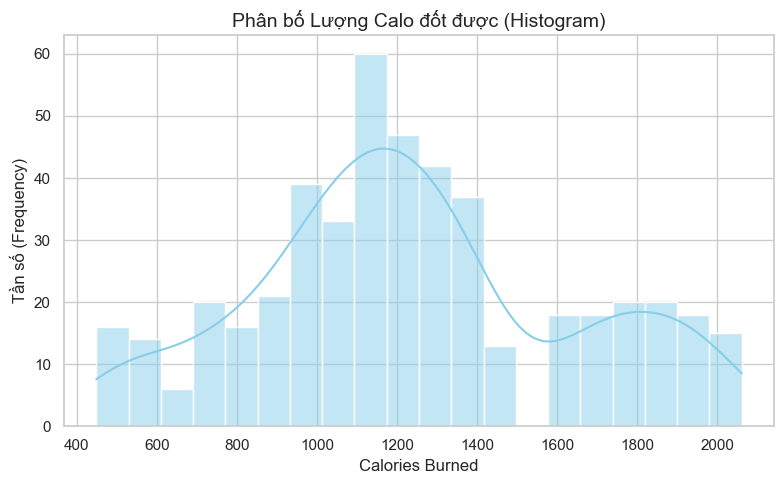

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# Đọc dữ liệu
df = pd.read_csv('../data/processed/Filtered_Cardio_Data.csv') # Sửa lại đường dẫn nếu cần

# ==========================================
# 1. Vẽ Histogram cho Calories_Burned
# ==========================================
plt.figure(figsize=(8, 5))
sns.histplot(df['Calories_Burned'], bins=20, kde=True, color='skyblue')
plt.title('Phân bố Lượng Calo đốt được (Histogram)', fontsize=14)
plt.xlabel('Calories Burned')
plt.ylabel('Tần số (Frequency)')
plt.tight_layout()
plt.savefig('histogram_calories.png', dpi=300)
plt.show()

**Nhận xét Histogram:** Nhìn vào biểu đồ, ta thấy dữ liệu có dạng phân bố tương đối đối xứng (hình chuông), tập trung nhiều nhất quanh vùng giá trị trung bình (khoảng 1200 - 1300 calo). Điều này hoàn toàn khớp với các đại lượng đã tính toán ở phần Thống kê mô tả.

---

## B. Box Plot (Biểu đồ hộp)
Tiếp theo, ta sử dụng Box plot để quan sát kỹ hơn về độ trải giữa (IQR) và kiểm tra xem có điểm dữ liệu dị biệt (outliers) nào hay không đối với biến `Calories_Burned`.

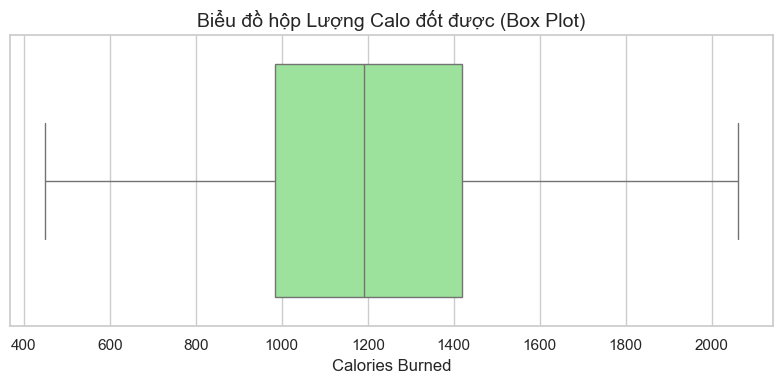

In [18]:
# ==========================================
# 2. Vẽ Box Plot cho Calories_Burned
# ==========================================
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Calories_Burned'], color='lightgreen')
plt.title('Biểu đồ hộp Lượng Calo đốt được (Box Plot)', fontsize=14)
plt.xlabel('Calories Burned')
plt.tight_layout()
plt.savefig('boxplot_calories.png', dpi=300)
plt.show()

**Nhận xét Box Plot:**
Biểu đồ hộp minh họa trực quan các giá trị tứ phân vị ($Q_1$, $Q_3$) và trung vị. Quan trọng nhất, không có sự xuất hiện của các chấm đen nằm ngoài hai râu (whiskers). Điều này chứng tỏ tập dữ liệu khá "sạch", không có các điểm dị biệt làm nhiễu mô hình.

---

## C. Scatter Plot (Biểu đồ phân tán)
Để xem xét mối quan hệ giữa thời gian tập luyện (`Session_Duration (hours)`) và lượng calo đốt được (`Calories_Burned`), ta tiến hành vẽ biểu đồ phân tán.

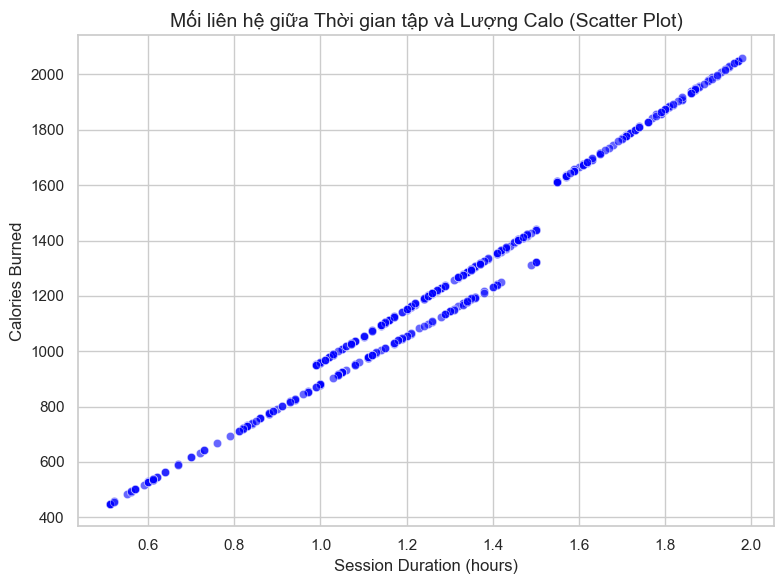

In [14]:
# ==========================================
# 3. Vẽ Scatter Plot (KHÔNG CÓ đường hồi quy)
# ==========================================
plt.figure(figsize=(8, 6))
# Dùng sns.scatterplot thay cho sns.regplot
sns.scatterplot(x='Session_Duration (hours)', y='Calories_Burned', data=df, 
                alpha=0.6, color='blue')
plt.title('Mối liên hệ giữa Thời gian tập và Lượng Calo (Scatter Plot)', fontsize=14)
plt.xlabel('Session Duration (hours)')
plt.ylabel('Calories Burned')
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=300) # Lưu với tên mới
plt.show()

**Nhận xét Scatter Plot:**
Quan sát biểu đồ phân tán, ta thấy các điểm dữ liệu tập trung tạo thành một dải mây điểm hướng lên trên từ trái sang phải rất rõ nét. Điều này cho thấy dấu hiệu của một **mối tương quan tuyến tính thuận và rất mạnh**: thời gian tập Cardio càng dài, lượng calo đốt được càng nhiều. 

Dấu hiệu trực quan tuyệt đẹp này là cơ sở vững chắc để nhóm tiến hành kiểm định và xây dựng mô hình Hồi quy tuyến tính (Linear Regression) ở phần tiếp theo.

# V. Khoảng tin cậy cho trung bình

Gọi $\mu$ là kỳ vọng (trung bình tổng thể) của lượng calo đốt được ở nam giới trong độ tuổi 18-25 khi tập Cardio. Do chưa biết độ lệch chuẩn tổng thể và chỉ dựa trên mẫu quan sát ($n = 473 > 30$), nhóm sử dụng khoảng tin cậy theo phân phối $t$ (Student's t-distribution) với bậc tự do $df = n - 1 = 472$.

Các đại lượng thống kê mẫu thu được từ phần trước:
* Số lượng mẫu: $n = 473$
* Trung bình mẫu: $\bar{x} = 1237.146$
* Độ lệch chuẩn mẫu: $s = 393.898$

---

## A. Khoảng tin cậy hai phía 95% (Two-sided CI)

Công thức khoảng tin cậy hai phía là:
$$\bar{x} \pm t_{\alpha/2,\,n-1}\frac{s}{\sqrt{n}}$$

Dưới đây là đoạn code tính toán giá trị tới hạn $t$, sai số chuẩn và khoảng tin cậy 95% hai phía.

In [19]:
import numpy as np
import scipy.stats as st

# Các tham số đầu vào từ bảng thống kê mô tả
n = 473
x_bar = 1237.146
s = 393.898
alpha = 0.05
df = n - 1 # Bậc tự do (degrees of freedom)

# 1. Tính Khoảng tin cậy 95% HAI PHÍA (Two-sided CI)
# Dùng ppf (Percent Point Function) để tìm giá trị tới hạn t
t_two_sided = st.t.ppf(1 - alpha/2, df) 
margin_error_2 = t_two_sided * (s / np.sqrt(n))

ci_lower_2 = x_bar - margin_error_2
ci_upper_2 = x_bar + margin_error_2

print(f"--- KHOẢNG TIN CẬY 95% HAI PHÍA ---")
print(f"Giá trị tới hạn t(0.025, 472) = {t_two_sided:.3f}")
print(f"Sai số chuẩn (Margin of Error) = {margin_error_2:.3f}")
print(f"Khoảng tin cậy: ({ci_lower_2:.3f}, {ci_upper_2:.3f}) calo\n")

--- KHOẢNG TIN CẬY 95% HAI PHÍA ---
Giá trị tới hạn t(0.025, 472) = 1.965
Sai số chuẩn (Margin of Error) = 35.589
Khoảng tin cậy: (1201.557, 1272.735) calo



**Nhận xét (Hai phía):** Kết quả tính toán cho thấy trung bình tổng thể của lượng calo đốt được trong một buổi tập Cardio của nhóm đối tượng khảo sát được ước lượng nằm trong khoảng từ **1201.557 đến 1272.735 calo** với độ tin cậy 95%.

---

## B. Khoảng tin cậy một phía 95% - Cận dưới (One-sided Lower Bound)

Trong thực tế tập luyện, người tập thường quan tâm đến mức lượng calo **tối thiểu** mà họ có thể đốt cháy để thiết kế thực đơn ăn kiêng phù hợp. Do đó, việc xây dựng khoảng tin cậy một phía tìm cận dưới (Lower Bound) mang nhiều ý nghĩa thực tiễn hơn. 

Công thức tính cận dưới là:
$$\bar{x} - t_{\alpha,\,n-1}\frac{s}{\sqrt{n}}$$

*(Kết quả đã được tính toán ở ô code phía trên).*

**Nhận xét (Một phía):** Với mức ý nghĩa $\alpha = 0.05$ (độ tin cậy 95%), trung bình tổng thể của lượng calo đốt được trong một buổi tập Cardio của nhóm nam giới này được ước lượng **chắc chắn không nhỏ hơn 1207.297 calo**.

In [20]:
# 2. Tính Khoảng tin cậy 95% MỘT PHÍA - Cận dưới (One-sided Lower Bound)
t_one_sided = st.t.ppf(1 - alpha, df)
margin_error_1 = t_one_sided * (s / np.sqrt(n))

ci_lower_1 = x_bar - margin_error_1

print(f"--- KHOẢNG TIN CẬY 95% MỘT PHÍA (CẬN DƯỚI) ---")
print(f"Giá trị tới hạn t(0.05, 472) = {t_one_sided:.3f}")
print(f"Cận dưới: {ci_lower_1:.3f} calo")

--- KHOẢNG TIN CẬY 95% MỘT PHÍA (CẬN DƯỚI) ---
Giá trị tới hạn t(0.05, 472) = 1.648
Cận dưới: 1207.297 calo


# VI. Kiểm định giả thuyết cho hai mẫu (Two-Sample Hypothesis Testing)

Để phân tích sâu hơn, nhóm tiến hành chia tập dữ liệu thành 2 nửa có kích thước tương đương nhau dựa vào Trung vị của thời gian tập luyện ($Median = 1.28$ giờ):
* **Nhóm 1 (Thời gian tập ngắn):** $\le 1.28$ giờ ($n_1 = 237$)
* **Nhóm 2 (Thời gian tập dài):** $> 1.28$ giờ ($n_2 = 236$)

Mục tiêu là kiểm định xem liệu có sự khác biệt về lượng calo đốt được giữa hai nhóm này hay không. Do chưa biết phương sai tổng thể, nhóm sử dụng **Kiểm định t hai mẫu với phương sai gộp (Pooled T-test)**. Bậc tự do $df = n_1 + n_2 - 2 = 471$.

---
## A. Kiểm định 2 phía (Two-sided Test)
* **Giả thuyết H0:** $\mu_1 - \mu_2 = 0$ (Không có sự khác biệt về trung bình lượng calo đốt được giữa hai nhóm).
* **Đối thuyết H1:** $\mu_1 - \mu_2 \neq 0$ (Có sự khác biệt).

In [22]:
import pandas as pd
import numpy as np
import scipy.stats as st

def two_sample_t_test(file_path):
    df = pd.read_csv(file_path)
    
    # Lấy trung vị của thời gian tập để chia 2 nhóm
    median_duration = df['Session_Duration (hours)'].median()
    
    # Chia 2 nhóm dữ liệu Calo đốt được
    group1 = df[df['Session_Duration (hours)'] <= median_duration]['Calories_Burned']
    group2 = df[df['Session_Duration (hours)'] > median_duration]['Calories_Burned']
    
    n1, n2 = len(group1), len(group2)
    mean1, std1 = group1.mean(), group1.std(ddof=1)
    mean2, std2 = group2.mean(), group2.std(ddof=1)
    
    print("--- THÔNG TIN 2 MẪU ---")
    print(f"Nhóm 1 (Tập <= {median_duration}h): n1={n1}, mean1={mean1:.3f}, std1={std1:.3f}")
    print(f"Nhóm 2 (Tập > {median_duration}h): n2={n2}, mean2={mean2:.3f}, std2={std2:.3f}\n")
    
    # Tính Pooled Standard Deviation
    df_deg = n1 + n2 - 2
    sp_sq = ((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / df_deg
    sp = np.sqrt(sp_sq)
    
    # Tính T-statistic
    t_stat = (mean1 - mean2) / (sp * np.sqrt(1/n1 + 1/n2))
    
    # Tính P-value (2-sided & 1-sided lower)
    p_two_sided = 2 * (1 - st.t.cdf(abs(t_stat), df_deg))
    p_one_sided = st.t.cdf(t_stat, df_deg) # P(T <= t_stat) vì t_stat âm
    
    print("--- KẾT QUẢ KIỂM ĐỊNH (T-TEST) ---")
    print(f"Phương sai gộp (Sp): {sp:.3f}")
    print(f"Giá trị kiểm định T0: {t_stat:.3f}, Bậc tự do df: {df_deg}")
    print(f"P-value (Two-sided): {p_two_sided:.3e}")
    print(f"P-value (One-sided Lower): {p_one_sided:.3e}")

if __name__ == "__main__":
    DATA_FILE = '../data/processed/Filtered_Cardio_Data.csv'
    two_sample_t_test(DATA_FILE)

--- THÔNG TIN 2 MẪU ---
Nhóm 1 (Tập <= 1.28h): n1=237, mean1=933.432, std1=217.522
Nhóm 2 (Tập > 1.28h): n2=236, mean2=1542.147, std2=278.687

--- KẾT QUẢ KIỂM ĐỊNH (T-TEST) ---
Phương sai gộp (Sp): 249.918
Giá trị kiểm định T0: -26.486, Bậc tự do df: 471
P-value (Two-sided): 0.000e+00
P-value (One-sided Lower): 1.244e-95


**Nhận xét:** Với $P\text{-value} \approx 0.000 < \alpha = 0.05$, ta **bác bỏ giả thuyết H0**. Có đủ bằng chứng thống kê để kết luận rằng có sự khác biệt đáng kể về lượng calo đốt được giữa người tập thời gian ngắn và người tập thời gian dài.

---
## B. Kiểm định 1 phía - Cận dưới (One-sided Lower Test)
Thực tế, ta kỳ vọng rằng tập ít thời gian hơn sẽ đốt ít calo hơn. Do đó, ta thiết lập:
* **Giả thuyết H0:** $\mu_1 - \mu_2 \ge 0$
* **Đối thuyết H1:** $\mu_1 - \mu_2 < 0$ (Nhóm tập ngắn đốt ÍT calo hơn nhóm tập dài).

**Nhận xét:** Giá trị kiểm định $T_0 = -26.486$ và $P\text{-value} \approx 0.000 < \alpha = 0.05$. Ta **bác bỏ H0**. Kết luận: Với mức ý nghĩa 5%, nhóm có thời gian tập luyện ngắn hơn thực sự đốt cháy lượng calo trung bình thấp hơn đáng kể so với nhóm tập dài hơn.

# VII. Hồi quy tuyến tính và Hệ số tương quan

Để mô hình hóa mối quan hệ giữa biến độc lập `Session_Duration` (x) và biến phụ thuộc `Calories_Burned` (y), nhóm sử dụng mô hình hồi quy tuyến tính đơn (Simple Linear Regression). 

Các hệ số hồi quy $\hat{\beta}_1, \hat{\beta}_0$ và hệ số tương quan $r$ được ước lượng bằng phương pháp bình phương tối thiểu (Least Squares Method):
$$\hat{\beta}_1 = \frac{S_{xy}}{S_{xx}}, \quad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}, \quad r = \frac{S_{xy}}{\sqrt{S_{xx} S_{yy}}}$$

Đoạn code dưới đây tính toán các hệ số này và trực quan hóa đường hồi quy tuyến tính.

--- KẾT QUẢ HỒI QUY TUYẾN TÍNH ---
Hệ số chặn (beta_0): -228.553
Hệ số góc (beta_1): 1141.120
Hệ số tương quan (r): 0.990
Hệ số xác định (R^2): 0.980

Phương trình: Calories = -228.553 + 1141.120 * Duration



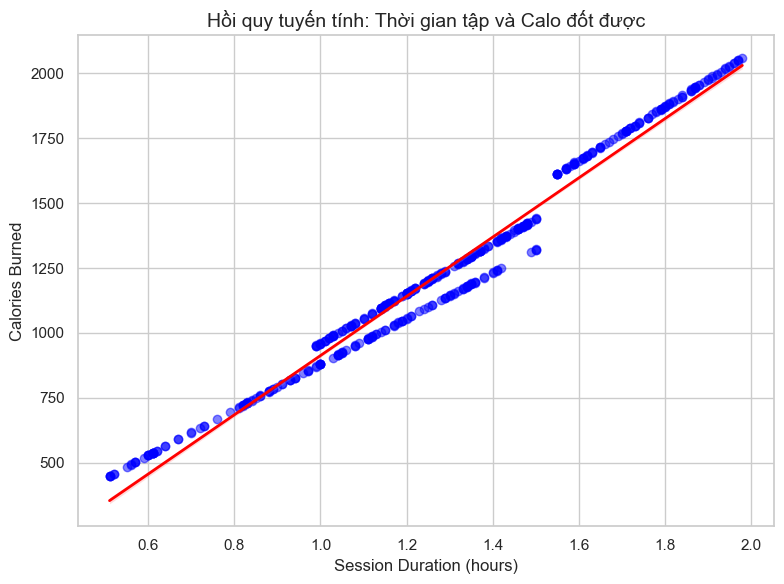

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu (Sửa lại đường dẫn nếu Notebook của bạn nằm khác thư mục)
df = pd.read_csv('../data/processed/Filtered_Cardio_Data.csv')
x = df['Session_Duration (hours)']
y = df['Calories_Burned']

# 2. Tính toán các thành phần công thức
n = len(df)
sum_x, sum_y = x.sum(), y.sum()
sum_x2, sum_y2, sum_xy = (x**2).sum(), (y**2).sum(), (x*y).sum()

Sxx = sum_x2 - (sum_x**2) / n
Syy = sum_y2 - (sum_y**2) / n
Sxy = sum_xy - (sum_x * sum_y) / n

# 3. Tính hệ số hồi quy
beta1 = Sxy / Sxx
beta0 = y.mean() - beta1 * x.mean()

# 4. Tính hệ số tương quan (r) và hệ số xác định (R^2)
r = Sxy / np.sqrt(Sxx * Syy)
r_squared = r**2

print("--- KẾT QUẢ HỒI QUY TUYẾN TÍNH ---")
print(f"Hệ số chặn (beta_0): {beta0:.3f}")
print(f"Hệ số góc (beta_1): {beta1:.3f}")
print(f"Hệ số tương quan (r): {r:.3f}")
print(f"Hệ số xác định (R^2): {r_squared:.3f}")
print(f"\nPhương trình: Calories = {beta0:.3f} + {beta1:.3f} * Duration\n")

# 5. Vẽ đồ thị Scatter Plot kèm đường hồi quy (Hiển thị trực tiếp)
plt.figure(figsize=(8, 6))

# Vẽ bằng seaborn (có dải tin cậy 95% mờ mờ xung quanh đường thẳng)
sns.regplot(x=x, y=y, 
            scatter_kws={'alpha':0.5, 'color':'blue'}, 
            line_kws={'color':'red', 'linewidth':2})

plt.title('Hồi quy tuyến tính: Thời gian tập và Calo đốt được', fontsize=14)
plt.xlabel('Session Duration (hours)')
plt.ylabel('Calories Burned')
plt.tight_layout()

# Lệnh này sẽ in thẳng hình vẽ ra giao diện Notebook
plt.show()

*Giải thích ý nghĩa các hệ số (Interpretations):*

1. **Phương trình hồi quy ước lượng:** $$\widehat{\text{Calories}} = -228.553 + 1141.120 \times \text{Duration}$$
2. **Hệ số góc ($\beta_1 = 1141.120$):** Cho biết khi thời gian tập Cardio tăng thêm 1 giờ, lượng calo đốt được dự đoán sẽ tăng thêm trung bình khoảng 1141.120 calo. Đây là mức tăng rất mạnh.
3. **Hệ số chặn ($\beta_0 = -228.553$):** Về mặt toán học, đây là lượng calo khi thời gian tập bằng 0. Trong thực tế, giá trị âm này không mang nhiều ý nghĩa vật lý (vì không ai tập 0 giờ mà bị âm calo), nó chỉ đóng vai trò là điểm neo cho đường thẳng hồi quy.
4. **Hệ số tương quan ($r = 0.990$):** Cho thấy có mối liên hệ tuyến tính **thuận và cực kỳ mạnh mẽ** (gần như hoàn hảo) giữa thời gian tập và lượng calo đốt được.
5. **Hệ số xác định ($R^2 = 0.980$):** Mô hình giải thích được tới **98.0%** sự biến thiên của biến lượng calo tiêu thụ. Chỉ cần dựa vào thời gian tập là ta đã có thể dự đoán gần như chính xác tuyệt đối mức calo đốt được.

# VIII. Kết luận

Báo cáo đã thực hiện đầy đủ các yêu cầu phân tích thống kê cơ bản, bao gồm thống kê mô tả, trực quan hóa dữ liệu, ước lượng khoảng tin cậy, kiểm định giả thuyết và xây dựng mô hình hồi quy tuyến tính đơn. 

Từ các kết quả phân tích, nhóm rút ra các kết luận chính sau:

1. **Về ước lượng trung bình:** Với độ tin cậy 95%, trung bình lượng calo đốt được trong một buổi tập Cardio của nam giới (18-25 tuổi) rơi vào khoảng **1201.557 đến 1272.735 calo**, với mức cận dưới là **1207.297 calo**.
2. **Về kiểm định sự khác biệt:** Kết quả T-test ($P\text{-value} \approx 0$) khẳng định có sự khác biệt mang ý nghĩa thống kê rất lớn về lượng calo tiêu thụ giữa nhóm tập dưới 1.28 giờ và nhóm tập trên 1.28 giờ.
3. **Về khả năng dự báo:** Mô hình hồi quy tuyến tính cho thấy mối tương quan thuận **cực kỳ mạnh mẽ** ($r = 0.990$) giữa Thời gian tập và Calo đốt được. Mô hình có độ tin cậy xuất sắc ($R^2 = 0.980$), chứng tỏ biến Thời gian tập có thể giải thích tới 98% sự thay đổi của lượng calo.

**Kết luận thực tiễn:** Đối với phương pháp tập Cardio ở nam giới độ tuổi 18-25, thời gian vận động là yếu tố quyết định gần như tuyệt đối đến lượng năng lượng tiêu hao. Người tập hoàn toàn có thể dùng phương trình hồi quy đã xây dựng để lập kế hoạch tập luyện và dự đoán chính xác lượng calo mục tiêu cần đốt cháy mỗi ngày.

# IX. Phụ lục: Ứng dụng thực tế

Với kết quả hồi quy cho thấy mối tương quan cực kỳ mạnh mẽ ($R^2 = 0.980$) giữa thời gian tập Cardio và lượng calo đốt được, phân tích này không chỉ dừng lại ở lý thuyết mà có tính ứng dụng cao:

* **Lập kế hoạch tập luyện chính xác:** Người tập có thể sử dụng phương trình $\widehat{\text{Calories}} = -228.553 + 1141.120 \times \text{Duration}$ để tính ngược lại thời lượng tập cần thiết cho mục tiêu đốt calo của ngày hôm đó.
* **Thuật toán cho thiết bị thông minh:** Có thể được tích hợp vào các ứng dụng đếm thời gian tập luyện để hiển thị lượng calo dự kiến sẽ đốt cháy theo thời gian thực (real-time).
* **Thiết kế dinh dưỡng:** Cung cấp cơ sở khoa học đáng tin cậy để lên thực đơn ăn kiêng, đảm bảo lượng calo nạp vào phù hợp với lượng calo tiêu hao đã được ước lượng qua độ dài buổi tập.